# **Group Work Project 1: Derivative Pricing**

## **Team Members**  


### **Sana ur rehman Arain**  
**Location:** Sweden

**Email:** [sanaurrehman01@gmail.com](mailto:sanaurrehman01@gmail.com)  

<br>

*This notebook explores derivative pricing using binomial and trinomial tree models. It implements functions for pricing European and American options, calculates and visualizes the convergence of option prices with increasing steps, computes option Greeks (Delta and Vega), and examines put-call parity for both European and American options across different moneyness levels. Finally, it demonstrates a delta hedging simulation for an American put option along an all-down path.*

In [1]:
import math
from math import exp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## **Pricing Binomial Options**

In [2]:
def binomial_option_pricer(S_ini, K, T, r, sigma, N, opttype, style):
    """
    Prices a European or American option using the binomial tree model.

    Args:
        S_ini (float): Initial stock price
        K (float): Strike price
        T (float): Time to maturity in years
        r (float): Risk-free interest rate
        sigma (float): Volatility
        N (int): Number of time steps in the binomial tree
        opttype (str): 'C' for Call, 'P' for Put
        style (str): 'A' for American, 'E' for European

    Returns:
        tuple: (Option price, The full option price tree, The full stock price tree)
    """
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    S = np.zeros((N + 1, N + 1))
    C = np.zeros((N + 1, N + 1))

    for i in range(N + 1):
        S[i, N] = S_ini * (u**(N - i)) * (d**i)
        if opttype.upper() == 'C':
            C[i, N] = max(0, S[i, N] - K)
        else: # Put option
            C[i, N] = max(0, K - S[i, N])

    for j in range(N - 1, -1, -1):
        for i in range(j + 1):
            S[i, j] = S_ini * (u**(j - i)) * (d**i)

            continuation_value = np.exp(-r * dt) * (p * C[i, j + 1] + (1 - p) * C[i + 1, j + 1])

            if style.upper() == 'A':
                if opttype.upper() == 'C':
                    intrinsic_value = max(0, S[i, j] - K)
                else:
                    intrinsic_value = max(0, K - S[i, j])
                C[i, j] = max(continuation_value, intrinsic_value)
            else:
                C[i, j] = continuation_value

    return C[0, 0], C, S

### **European Option, Binomial**

In [3]:
price_array = []
for N in [1] + list(range(10, 300, 10)):
    call_price, C, S = binomial_option_pricer(
        S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=N,
        opttype="C", style="E"
    )
    price_array.append(call_price)
    print(f"With N = {N:3d}, the price is {call_price:.2f}")


With N =   1, the price is 5.59
With N =  10, the price is 4.52
With N =  20, the price is 4.57
With N =  30, the price is 4.58
With N =  40, the price is 4.59
With N =  50, the price is 4.60
With N =  60, the price is 4.60
With N =  70, the price is 4.60
With N =  80, the price is 4.60
With N =  90, the price is 4.60
With N = 100, the price is 4.61
With N = 110, the price is 4.61
With N = 120, the price is 4.61
With N = 130, the price is 4.61
With N = 140, the price is 4.61
With N = 150, the price is 4.61
With N = 160, the price is 4.61
With N = 170, the price is 4.61
With N = 180, the price is 4.61
With N = 190, the price is 4.61
With N = 200, the price is 4.61
With N = 210, the price is 4.61
With N = 220, the price is 4.61
With N = 230, the price is 4.61
With N = 240, the price is 4.61
With N = 250, the price is 4.61
With N = 260, the price is 4.61
With N = 270, the price is 4.61
With N = 280, the price is 4.61
With N = 290, the price is 4.61


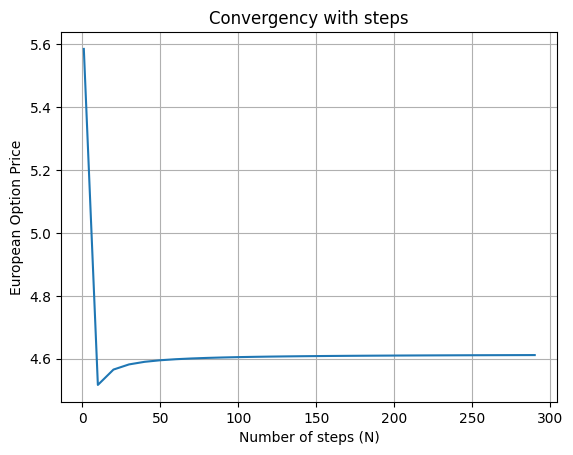

In [4]:
N = [1] + list(range(10, 300, 10))
plt.plot(N, np.array(price_array))
plt.title("Convergency with steps")
plt.xlabel("Number of steps (N)")
plt.ylabel("European Option Price")
plt.grid(True)
plt.show()

In [5]:
price_array = []
for N in [1] + list(range(10, 300, 10)):
    put_price, C, S = binomial_option_pricer(
        S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=N,
        opttype="P", style="E"
    )
    price_array.append(put_price)
    print(f"With N = {N:3d}, the price is {put_price:.2f}")


With N =   1, the price is 4.34
With N =  10, the price is 3.27
With N =  20, the price is 3.32
With N =  30, the price is 3.34
With N =  40, the price is 3.35
With N =  50, the price is 3.35
With N =  60, the price is 3.36
With N =  70, the price is 3.36
With N =  80, the price is 3.36
With N =  90, the price is 3.36
With N = 100, the price is 3.36
With N = 110, the price is 3.36
With N = 120, the price is 3.36
With N = 130, the price is 3.37
With N = 140, the price is 3.37
With N = 150, the price is 3.37
With N = 160, the price is 3.37
With N = 170, the price is 3.37
With N = 180, the price is 3.37
With N = 190, the price is 3.37
With N = 200, the price is 3.37
With N = 210, the price is 3.37
With N = 220, the price is 3.37
With N = 230, the price is 3.37
With N = 240, the price is 3.37
With N = 250, the price is 3.37
With N = 260, the price is 3.37
With N = 270, the price is 3.37
With N = 280, the price is 3.37
With N = 290, the price is 3.37


### Computing Delta

In the binomial tree, at $t = 0$ delta is computed from **time step 1** values:

$$
\Delta = \frac{V_{\text{up}} - V_{\text{down}}}{S_{\text{up}} - S_{\text{down}}}
$$

Where:

* $V_{\text{up}} = V[1, 1]$  (option value after one up move)
* $V_{\text{down}} = V[1, 0]$ (option value after one down move)
* $S_{\text{up}} = S[1, 1]$
* $S_{\text{down}} = S[1, 0]$


In [6]:
def delta(S0, K, T, r, sigma, N, option_type='C', style='E'):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    _, C, S = binomial_option_pricer(S0, K, T, r, sigma, N, option_type, style)

    Cu = C[0,1]   # option value at up move
    Cd = C[1,1]   # option value at down move
    Su = S[0,1]   # stock price up
    Sd = S[1,1]   # stock price down

    return (Cu - Cd) / (Su - Sd)


In [7]:
S0, K, T, r, sigma, N = 100, 100, 0.25, 0.05, 0.2, 100

delta_call = delta(S0, K, T, r, sigma, N, option_type='C', style='E')
delta_put  = delta(S0, K, T, r, sigma, N, option_type='P', style='E')

print("Delta (Call):", round(delta_call, 4))
print("Delta (Put):", round(delta_put, 4))


Delta (Call): 0.5693
Delta (Put): -0.4307


### Computing Vega

In [8]:
call_price_20, C, S = binomial_option_pricer(S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=100, opttype="C", style="European")
call_price_25, C, S = binomial_option_pricer(S_ini=100, K=100, T=0.25, r=0.05, sigma=0.25, N=100, opttype="C", style="European")

print(f"With sigma = 0.2, the price is {call_price_20:.2f}")
print(f"With sigma = 0.25, the price is {call_price_25:.2f}")

With sigma = 0.2, the price is 4.61
With sigma = 0.25, the price is 5.59


In [9]:
call_price_25 - call_price_20

np.float64(0.9809473982205308)

In [10]:
def vega(S0, K, T, r, sigma, N, option_type='C', style='E', h=1e-4):
    """
    Computes Vega of an option using the binomial tree pricer with finite differences.

    Args:
        S0 (float): Initial stock price
        K (float): Strike price
        T (float): Time to maturity
        r (float): Risk-free rate
        sigma (float): Volatility
        N (int): Number of steps
        option_type (str): 'C' for Call, 'P' for Put
        style (str): 'E' for European, 'A' for American
        h (float): small bump size for finite difference

    Returns:
        float: Vega at time 0
    """
    # Price with sigma + h
    C_up, _, _ = binomial_option_pricer(S0, K, T, r, sigma + h, N, option_type, style)

    # Price with sigma - h
    C_down, _, _ = binomial_option_pricer(S0, K, T, r, sigma - h, N, option_type, style)

    # Finite difference approximation
    vega = (C_up - C_down) / (2 * h)
    return vega


In [11]:
S0, K, T, r, sigma, N = 100, 100, 0.25, 0.05, 0.2, 100

vega_call = vega(S0, K, T, r, sigma, N, option_type='C', style='E')
vega_put  = vega(S0, K, T, r, sigma, N, option_type='P', style='E')

print("Vega (Call):", round(vega_call, 4))
print("Vega (Put):", round(vega_put, 4))

Vega (Call): 19.5949
Vega (Put): 19.5949


## **American Options, Binomial**

In [12]:
price_array = []
for N in [1] + list(range(10, 300, 10)):
    call_price, C, S = binomial_option_pricer(
        S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=N,
        opttype="C", style="A"
    )
    price_array.append(call_price)
    print(f"With N = {N:3d}, the price is {call_price:.2f}")

With N =   1, the price is 5.59
With N =  10, the price is 4.52
With N =  20, the price is 4.57
With N =  30, the price is 4.58
With N =  40, the price is 4.59
With N =  50, the price is 4.60
With N =  60, the price is 4.60
With N =  70, the price is 4.60
With N =  80, the price is 4.60
With N =  90, the price is 4.60
With N = 100, the price is 4.61
With N = 110, the price is 4.61
With N = 120, the price is 4.61
With N = 130, the price is 4.61
With N = 140, the price is 4.61
With N = 150, the price is 4.61
With N = 160, the price is 4.61
With N = 170, the price is 4.61
With N = 180, the price is 4.61
With N = 190, the price is 4.61
With N = 200, the price is 4.61
With N = 210, the price is 4.61
With N = 220, the price is 4.61
With N = 230, the price is 4.61
With N = 240, the price is 4.61
With N = 250, the price is 4.61
With N = 260, the price is 4.61
With N = 270, the price is 4.61
With N = 280, the price is 4.61
With N = 290, the price is 4.61


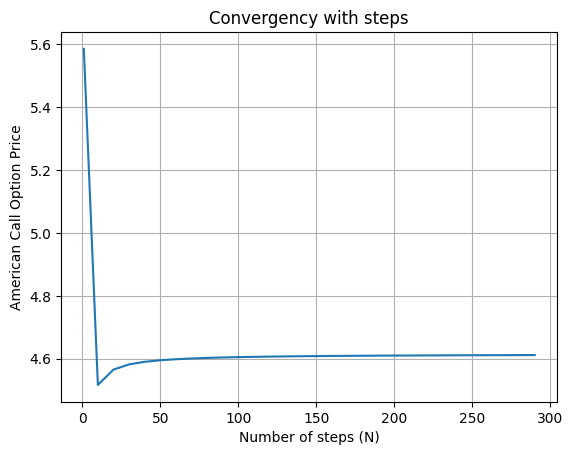

In [13]:
N = [1] + list(range(10, 300, 10))
plt.plot(N, np.array(price_array))
plt.title("Convergency with steps")
plt.xlabel("Number of steps (N)")
plt.ylabel("American Call Option Price")
plt.grid(True)
plt.show()

Convergence at N=100

In [14]:
price_array = []
for N in [1] + list(range(10, 300, 10)):
    put_price, C, S = binomial_option_pricer(
        S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=N,
        opttype="P", style="A"
    )
    price_array.append(put_price)
    print(f"With N = {N:3d}, the price is {put_price:.2f}")

With N =   1, the price is 4.34
With N =  10, the price is 3.43
With N =  20, the price is 3.45
With N =  30, the price is 3.46
With N =  40, the price is 3.47
With N =  50, the price is 3.47
With N =  60, the price is 3.47
With N =  70, the price is 3.47
With N =  80, the price is 3.47
With N =  90, the price is 3.47
With N = 100, the price is 3.47
With N = 110, the price is 3.48
With N = 120, the price is 3.48
With N = 130, the price is 3.48
With N = 140, the price is 3.48
With N = 150, the price is 3.48
With N = 160, the price is 3.48
With N = 170, the price is 3.48
With N = 180, the price is 3.48
With N = 190, the price is 3.48
With N = 200, the price is 3.48
With N = 210, the price is 3.48
With N = 220, the price is 3.48
With N = 230, the price is 3.48
With N = 240, the price is 3.48
With N = 250, the price is 3.48
With N = 260, the price is 3.48
With N = 270, the price is 3.48
With N = 280, the price is 3.48
With N = 290, the price is 3.48


Convergence at N=110

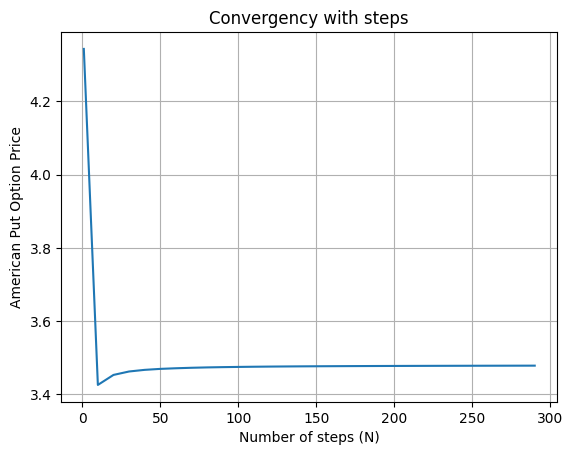

In [15]:
N = [1] + list(range(10, 300, 10))
plt.plot(N, np.array(price_array))
plt.title("Convergency with steps")
plt.xlabel("Number of steps (N)")
plt.ylabel("American Put Option Price")
plt.grid(True)
plt.show()

### **Delta**

In [16]:
S0, K, T, r, sigma, N = 100, 100, 0.25, 0.05, 0.2, 100

delta_call = delta(S0, K, T, r, sigma, N, option_type='C', style='A')
delta_put  = delta(S0, K, T, r, sigma, N, option_type='P', style='A')

print("Delta (Call):", round(delta_call, 4))
print("Delta (Put):", round(delta_put, 4))

Delta (Call): 0.5693
Delta (Put): -0.4498


In [17]:
delta_call - delta_put

np.float64(1.0191211696668645)

### **Vega**

In [18]:
call_price_20, C, S = binomial_option_pricer(S_ini=100, K=100, T=0.25, r=0.05, sigma=0.2, N=100, opttype="C", style="A")
call_price_25, C, S = binomial_option_pricer(S_ini=100, K=100, T=0.25, r=0.05, sigma=0.25, N=100, opttype="C", style="A")

print(f"With sigma = 0.2, the price is {call_price_20:.2f}")
print(f"With sigma = 0.25, the price is {call_price_25:.2f}")

With sigma = 0.2, the price is 4.61
With sigma = 0.25, the price is 5.59


In [19]:
S0, K, T, r, sigma, N = 100, 100, 0.25, 0.05, 0.2, 100

vega_call = vega(S0, K, T, r, sigma, N, option_type='C', style='A')
vega_put  = vega(S0, K, T, r, sigma, N, option_type='P', style='A')

print("Vega (Call):", round(vega_call, 4))
print("Vega (Put):", round(vega_put, 4))

Vega (Call): 19.5949
Vega (Put): 19.5277


In [20]:
def plot_american_vs_european(S_range, K, T, r, sigma, N, opttype='P'):
    """
    Plot American vs European option prices across a range of stock prices.

    Args:
        S_range (list): List of initial stock prices
        K (float): Strike price
        T (float): Time to maturity (in years)
        r (float): Risk-free interest rate
        sigma (float): Volatility
        N (int): Number of steps in binomial tree
        opttype (str): 'C' for Call, 'P' for Put
    """
    american_prices = []
    european_prices = []

    for S in S_range:
        # American price
        price_a, _, _ = binomial_option_pricer(S, K, T, r, sigma, N, opttype, 'A')
        american_prices.append(price_a)

        # European price
        price_e, _, _ = binomial_option_pricer(S, K, T, r, sigma, N, opttype, 'E')
        european_prices.append(price_e)

    plt.style.use('seaborn-v0_8-darkgrid')
    plt.figure(figsize=(10, 6))

    if opttype.upper() == 'C':
        plt.plot(S_range, american_prices, label='American Call', linewidth=2.5)
        plt.plot(S_range, european_prices, label='European Call', linestyle='--', linewidth=2.5)
        plt.title('American vs. European Call Option Prices', fontsize=16)
    else:
        plt.plot(S_range, american_prices, label='American Put', linewidth=2.5)
        plt.plot(S_range, european_prices, label='European Put', linestyle='--', linewidth=2.5)
        plt.title('American vs. European Put Option Prices', fontsize=16)

    # Add strike price line
    plt.axvline(x=K, color='r', linestyle='-.', label=f'Strike Price K=${K}')

    # Labels
    plt.xlabel('Initial Stock Price ($S_0$)', fontsize=12)
    plt.ylabel('Option Price', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True)

    plt.show()


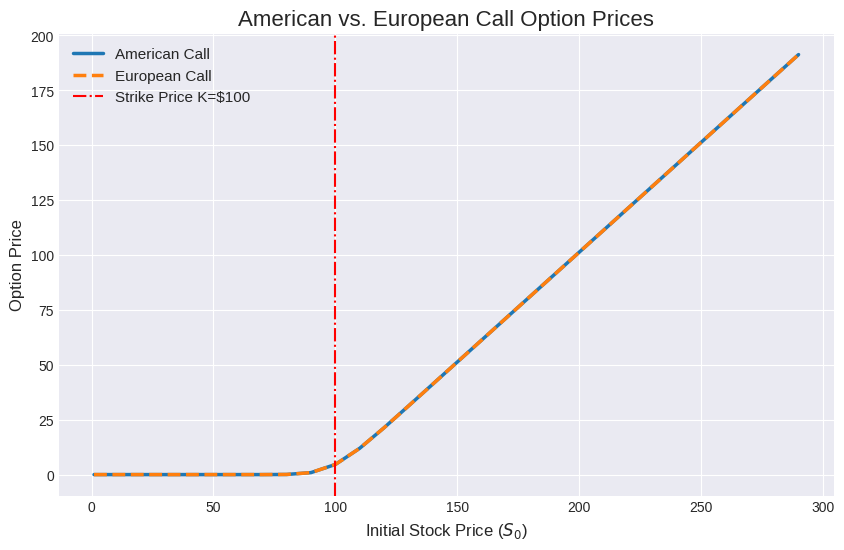

In [21]:
K = 100
T = 0.25
r = 0.05
sigma = 0.2
N = 100
S_range = [1] + list(range(10, 300, 10))

# Plot American vs European Put
plot_american_vs_european(S_range, K, T, r, sigma, N, opttype='C')

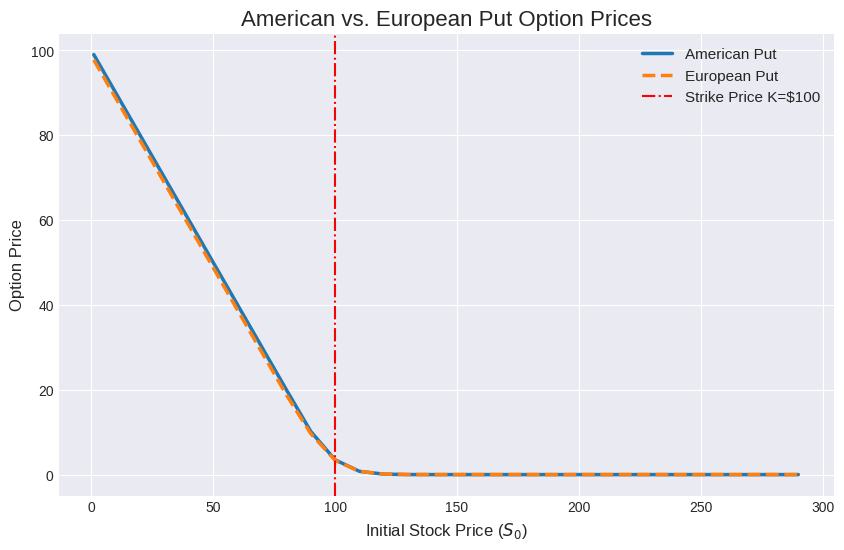

In [22]:
# Plot American vs European Put
plot_american_vs_european(S_range, K, T, r, sigma, N, opttype='P')

The plot shows a slight difference between both exercise styles. The American put is a little bit more then the European put

## **Option Pricing Across Moneyness Level Using Trinomial Trees**

In [23]:
# Trinomial pricer
def trinomial_price(S0, K, r, sigma, T, N, option_type='call', american=True):
    dt = T / N
    nu = r - 0.5 * sigma ** 2
    dx = sigma * math.sqrt(3 * dt)
    pu = 0.5 * ((sigma ** 2 * dt + (nu * dt) ** 2) / dx ** 2 + (nu * dt) / dx)
    pd = 0.5 * ((sigma ** 2 * dt + (nu * dt) ** 2) / dx ** 2 - (nu * dt) / dx)
    pm = 1.0 - pu - pd
    disc = math.exp(-r * dt)

    M = N
    ST = np.array([S0 * math.exp(j * dx) for j in range(-M, M + 1)])
    if option_type == 'call':
        payoff = np.maximum(ST - K, 0.0)
    else:
        payoff = np.maximum(K - ST, 0.0)

    values = payoff.copy()
    m = M
    for step in range(N, 0, -1):
        m -= 1
        new_values = np.zeros(2 * m + 1)
        for j in range(-m, m + 1):
            i_old = j + (m + 1)
            Vu = values[i_old + 1]
            Vm = values[i_old]
            Vd = values[i_old - 1]
            expected = disc * (pu * Vu + pm * Vm + pd * Vd)
            Snode = S0 * math.exp(j * dx)
            if american:
                if option_type == 'call':
                    new_values[j + m] = max(expected, Snode - K)
                else:
                    new_values[j + m] = max(expected, K - Snode)
            else:
                new_values[j + m] = expected
        values = new_values
    return values[0]


#### **Moneyness with European Options**

##### **Call Options**

In [24]:
strikes = [90, 95, 100, 105, 110]
call_data = []

for K in strikes:
  eu_call = trinomial_price(S0, K, r, sigma, T, N, 'call', american=False)
  moneyness = (S0 / K - 1) * 100
  call_data.append({'Strike': K, 'Moneyness (%)': round(moneyness,2), 'Call Price': round(eu_call, 2)})

eu_call_options = pd.DataFrame(call_data)
print("European Call Option Prices:")
eu_call_options

European Call Option Prices:


,Strike,Moneyness (%),Call Price
0,90,11.11,11.67
1,95,5.26,7.71
2,100,0.00,4.61
3,105,-4.76,2.48
4,110,-9.09,1.19


##### **Put Options**

In [25]:
put_data = []

for K in strikes:
  eu_put = trinomial_price(S0, K, r, sigma, T, N, 'put', american=False)
  moneyness = (K / S0 - 1) * 100
  put_data.append({'Strike': K, 'Moneyness (%)': moneyness, 'Put Price': round(eu_put, 2)})

eu_put_options = pd.DataFrame(put_data)
print("European Put Option Prices:")
eu_put_options

European Put Option Prices:


,Strike,Moneyness (%),Put Price
0,90,-10.0,0.55
1,95,-5.0,1.53
2,100,0.0,3.36
3,105,5.0,6.17
4,110,10.0,9.83


#### **Moneyness with American Options**

##### **Call Options**

In [26]:
call_data = []

for K in strikes:
  am_call = trinomial_price(S0, K, r, sigma, T, N, 'call', american=True)
  moneyness = (S0 / K - 1) * 100
  call_data.append({'Strike': K, 'Moneyness (%)': round(moneyness,2), 'Call Price': round(am_call, 2)})

am_call_options = pd.DataFrame(call_data)
print("American Call Option Prices:")
am_call_options

American Call Option Prices:


,Strike,Moneyness (%),Call Price
0,90,11.11,11.67
1,95,5.26,7.71
2,100,0.00,4.61
3,105,-4.76,2.48
4,110,-9.09,1.19


In [27]:
put_data = []

for K in strikes:
  am_put = trinomial_price(S0, K, r, sigma, T, N, 'put', american=True)
  moneyness = (K / S0 - 1) * 100
  put_data.append({'Strike': K, 'Moneyness (%)': round(moneyness,2), 'Put Price': round(am_put,2)})

am_put_options = pd.DataFrame(put_data)
print("American Put Option Prices:")
am_put_options

American Put Option Prices:


,Strike,Moneyness (%),Put Price
0,90,-10.0,0.56
1,95,-5.0,1.57
2,100,0.0,3.47
3,105,5.0,6.42
4,110,10.0,10.33


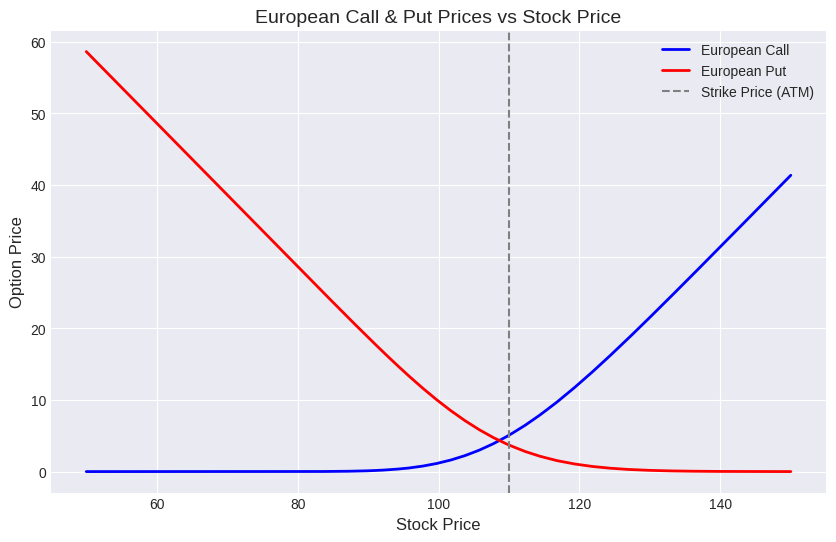

In [28]:
stock_prices = np.linspace(50, 150, 200)

call_prices = [binomial_option_pricer(S, K, T, r, sigma, N, "C", "E")[0] for S in stock_prices]
put_prices  = [binomial_option_pricer(S, K, T, r, sigma, N, "P", "E")[0] for S in stock_prices]

# Plot
plt.figure(figsize=(10,6))
plt.plot(stock_prices, call_prices, label="European Call", color="blue", linewidth=2)
plt.plot(stock_prices, put_prices, label="European Put", color="red", linewidth=2)
plt.axvline(x=K, color="gray", linestyle="--", label="Strike Price (ATM)")
plt.title("European Call & Put Prices vs Stock Price", fontsize=14)
plt.xlabel("Stock Price", fontsize=12)
plt.ylabel("Option Price", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

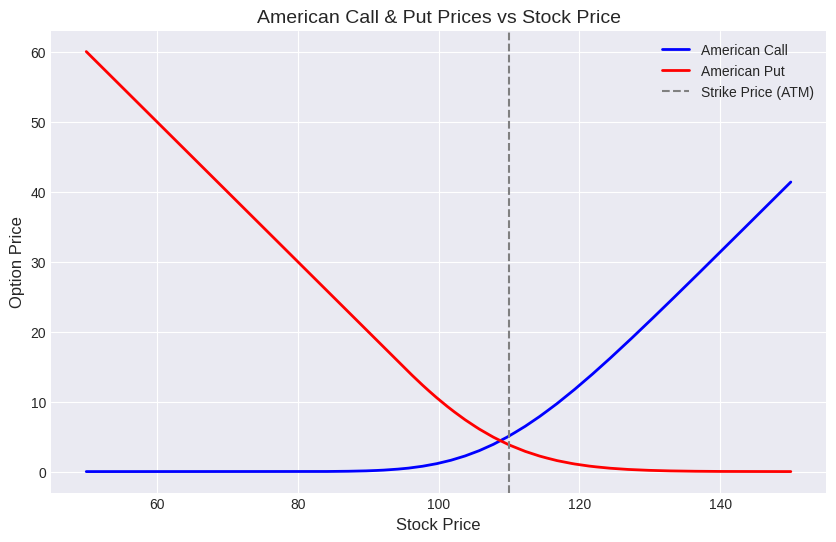

In [29]:
call_prices = [binomial_option_pricer(S, K, T, r, sigma, N, "C", "A")[0] for S in stock_prices]
put_prices  = [binomial_option_pricer(S, K, T, r, sigma, N, "P", "A")[0] for S in stock_prices]

# Plot
plt.figure(figsize=(10,6))
plt.plot(stock_prices, call_prices, label="American Call", color="blue", linewidth=2)
plt.plot(stock_prices, put_prices, label="American Put", color="red", linewidth=2)
plt.axvline(x=K, color="gray", linestyle="--", label="Strike Price (ATM)")
plt.title("American Call & Put Prices vs Stock Price", fontsize=14)
plt.xlabel("Stock Price", fontsize=12)
plt.ylabel("Option Price", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

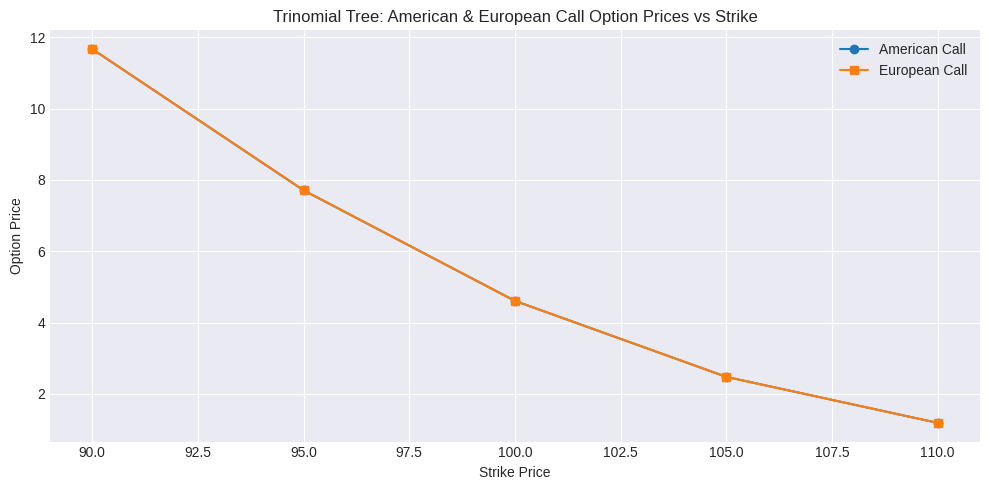

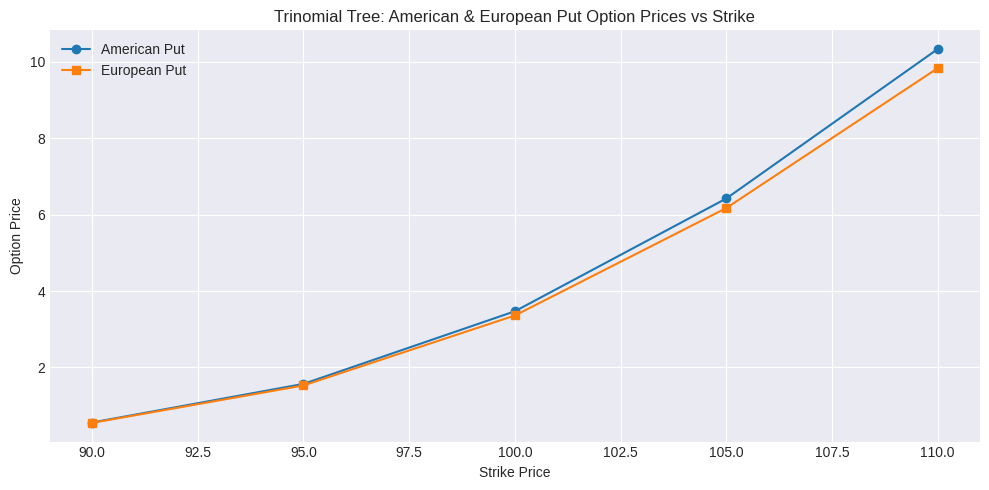

In [30]:
# Plot for Call Options
plt.figure(figsize=(10, 5))
plt.plot(am_call_options['Strike'], am_call_options['Call Price'], marker='o', label='American Call')
plt.plot(eu_call_options['Strike'], eu_call_options['Call Price'], marker='s', label='European Call')
plt.title('Trinomial Tree: American & European Call Option Prices vs Strike')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot for Put Options
plt.figure(figsize=(10, 5))
plt.plot(am_put_options['Strike'], am_put_options['Put Price'], marker='o', label='American Put')
plt.plot(eu_put_options['Strike'], eu_put_options['Put Price'], marker='s', label='European Put')
plt.title('Trinomial Tree: American & European Put Option Prices vs Strike')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Checking for Put-Call Parity Across Moneyness Levels**

In [31]:
def check_put_call_parity(S0, r, T, K, C, P):
    K = np.array(K)
    C = np.array(C)
    P = np.array(P)

    lhs = C - P
    rhs = S0 - K * np.exp(-r * T)
    diff = lhs - rhs

    results = pd.DataFrame({
        "Strike (K)": K,
        "Call (C)": C,
        "Put (P)": P,
        "C - P": lhs.round(4),
        "S0 - K*exp(-rT)": rhs.round(4),
        "Difference": diff.round(4),
        "Parity Holds?": np.isclose(lhs, rhs, atol=1e-2)  # within 0.01
    })

    return results

S0 = 100
r = 0.05
T = 0.25
K = [90, 95, 100, 105, 110]
C = [11.67, 7.72, 4.61, 2.48, 1.19]
P = [0.55, 1.53, 3.36, 6.17, 9.83]

df_eu_parity = check_put_call_parity(S0, r, T, K, C, P)
df_eu_parity


,Strike (K),Call (C),Put (P),C - P,S0 - K*exp(-rT),Difference,Parity Holds?
0,90,11.67,0.55,11.12,11.1180,0.0020,True
1,95,7.72,1.53,6.19,6.1801,0.0099,True
2,100,4.61,3.36,1.25,1.2422,0.0078,True
3,105,2.48,6.17,-3.69,-3.6957,0.0057,True
4,110,1.19,9.83,-8.64,-8.6336,-0.0064,True


In [32]:
C = [11.67, 7.72, 4.61, 2.48, 1.19]
P = [0.56, 1.57, 3.47, 6.42, 10.33]

df_am_parity = check_put_call_parity(S0, r, T, K, C, P)
df_am_parity

,Strike (K),Call (C),Put (P),C - P,S0 - K*exp(-rT),Difference,Parity Holds?
0,90,11.67,0.56,11.11,11.1180,-0.0080,True
1,95,7.72,1.57,6.15,6.1801,-0.0301,False
2,100,4.61,3.47,1.14,1.2422,-0.1022,False
3,105,2.48,6.42,-3.94,-3.6957,-0.2443,False
4,110,1.19,10.33,-9.14,-8.6336,-0.5064,False


___

### **Delta Hedging**

For American Option

In [33]:
put_price, C, S = binomial_option_pricer(S_ini=180, K=182, T=0.5, r=0.02, sigma=0.25, N=25,opttype="P", style="A")
put_price

np.float64(13.03571894719869)

In [36]:
def binomial_tree_deltas(S0, K, T, r, sigma, N, opttype="C", style="E"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    q = (np.exp(r * dt) - d) / (u - d)  # risk-neutral prob

    S = np.zeros((N + 1, N + 1))
    for i in range(N + 1):
        for j in range(i + 1):
            S[j, i] = S0 * (u ** (i - j)) * (d ** j)

    V = np.zeros((N + 1, N + 1))
    if opttype == "C":
        V[:, N] = np.maximum(S[:, N] - K, 0)
    else:
        V[:, N] = np.maximum(K - S[:, N], 0)

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            cont_val = np.exp(-r * dt) * (q * V[j, i + 1] + (1 - q) * V[j + 1, i + 1])
            if style == "E":
                V[j, i] = cont_val
            else:  # American
                if opttype == "C":
                    V[j, i] = max(S[j, i] - K, cont_val)
                else:
                    V[j, i] = max(K - S[j, i], cont_val)

    Delta = np.zeros((N, N))
    for i in range(N):  # step
        for j in range(i + 1):
            Su = S[j, i + 1]
            Sd = S[j + 1, i + 1]
            Vu = V[j, i + 1]
            Vd = V[j + 1, i + 1]
            Delta[j, i] = (Vu - Vd) / (Su - Sd)

    return S, V, Delta

S, V, Delta = binomial_tree_deltas(
    S0=180, K=182, T=0.5, r=0.02, sigma=0.25, N=25, opttype="P", style="A"
)

for i in range(5):  # first 5 steps
    print(f"Step {i}: {Delta[:i+1, i]}")


Step 0: [-0.47555673]
Step 1: [-0.39511033 -0.5608058 ]
Step 2: [-0.31629757 -0.47862823 -0.64788939]
Step 3: [-0.2422719  -0.39474259 -0.56752187 -0.73305488]
Step 4: [-0.17603917 -0.31245874 -0.48193881 -0.65821426 -0.8123635 ]


In [42]:
def compute_delta_from_trees(C, S):
    """
    Delta at each non-terminal node:
        Δ_{i,j} = (V_up - V_down) / (S_up - S_down)
    Shapes:
        C, S are (N+1, N+1); return Δ of shape (N, N) (defined for j=0..N-1)
    """
    N = C.shape[1] - 1
    Delta = np.zeros((N, N))
    for j in range(N)
        for i in range(j + 1):
            Vu = C[i,     j+1]
            Vd = C[i+1,   j+1]
            Su = S[i,     j+1]
            Sd = S[i+1,   j+1]
            Delta[i, j] = (Vu - Vd) / (Su - Sd)
    return Delta

def cash_account_table_all_down_path(S0, K, T, r, sigma, N, opttype="P", style="A"):
    """
    Builds a hedging table for the all-down path {d,d,...,d} for an American put sold (short one option).
    Conventions:
      - Use long-option delta for hedge; seller holds 'Shares held (seller)' = Δ_long_option (typically negative for puts),
        which corresponds to shorting |Δ| shares when Δ < 0.
      - Cash grows at exp(r*dt) between rebalancings.
      - Early exercise along the path is detected (if value equals intrinsic and >0); if it occurs,
        we record the payoff and stop hedging thereafter.

    Returns: pandas.DataFrame
    """
    price0, C, S = binomial_option_pricer(S0, K, T, r, sigma, N, opttype, style)
    dt = T / N
    disc_grow = np.exp(r * dt)

    Delta = compute_delta_from_trees(C, S)

    rows = []
    cash = 0.0
    shares_prev = 0.0

    # t=0: receive premium and set initial hedge to Δ_long at root
    t = 0
    i = 0
    S_ij = S[i, t]
    V_ij = C[i, t]
    delta_long = Delta[i, t] if N > 0 else 0.0

    # Premium in (seller), plus proceeds from shorting shares if Δ<0 (sell = cash inflow)
    premium = V_ij
    trade_cash = premium - delta_long * S_ij
    cash_after = cash + trade_cash
    rows.append({
        "Time step": t,
        "Node (i,j)": f"({i},{t})",
        "Underlying price": round(S_ij, 2),
        "Option value (long)": round(V_ij, 2),
        "Δ (long put)": round(delta_long, 4),
        "Shares held (seller)": round(delta_long, 4),
        "Stock portfolio value": round(delta_long * S_ij, 2),
        "Cash before trade": round(cash, 2),
        "Trade cash (inflow + / outflow -)": round(trade_cash, 2),
        "Cash after trade": round(cash_after, 2),
        "Note": "Receive premium; set initial hedge"
    })
    cash = cash_after
    shares_prev = delta_long

    exercised = False
    exercise_time = None
    exercise_payoff = 0.0

    for t in range(1, N + 1):
        i = t
        cash_before = cash * disc_grow

        S_ij = S[i, t]
        V_ij = C[i, t]

        intrinsic = max(K - S_ij, 0.0) if opttype.upper() == "P" else max(S_ij - K, 0.0)
        will_exercise_now = (style.upper() == "A") and (intrinsic > 0) and (abs(V_ij - intrinsic) < 1e-10)

        note = ""
        if (t < N):
            delta_long = Delta[i, t]
        else:
            delta_long = 0.0

        if not will_exercise_now:
            trade_shares = delta_long - shares_prev
            trade_cash = - trade_shares * S_ij
            cash_after = cash_before + trade_cash
            shares_now = delta_long
            note = "Rebalance hedge"
        else:
            payoff = intrinsic
            exercise_payoff = payoff
            exercise_time = t
            trade_shares = -shares_prev
            trade_cash = - trade_shares * S_ij
            cash_after = cash_before + trade_cash - payoff
            shares_now = 0.0
            exercised = True
            note = f"Early exercise: pay {payoff:.2f} and close hedge"

        rows.append({
            "Time step": t,
            "Node (i,j)": f"({i},{t})",
            "Underlying price": round(S_ij, 2),
            "Option value (long)": round(V_ij, 2),
            "Δ (long put)": round(delta_long, 4) if t < N and not will_exercise_now else ("—" if t==N or will_exercise_now else round(delta_long, 4)),
            "Shares held (seller)": round(shares_now, 4),
            "Stock portfolio value": round(shares_now * S_ij, 2),
            "Cash before trade": round(cash_before, 2),
            "Trade cash (inflow + / outflow -)": round(trade_cash, 2),
            "Cash after trade": round(cash_after, 2),
            "Note": note
        })

        cash = cash_after
        shares_prev = shares_now

        # If exercised, stop the path here
        if exercised:
            break

    df = pd.DataFrame(rows)
    return df, (exercise_time, exercise_payoff)

S0, K, T, r, sigma, N = 180, 182, 0.5, 0.02, 0.25, 25
df_path, exercise_info = cash_account_table_all_down_path(
    S0, K, T, r, sigma, N, opttype="P", style="A"
)

print(df_path.to_string(index=False))
if exercise_info[0] is not None:
    print(f"\nExercise occurred at step {exercise_info[0]} with payoff {exercise_info[1]:.2f}")
else:
    print("\nNo early exercise along the all-down path.")


 Time step Node (i,j)  Underlying price  Option value (long) Δ (long put)  Shares held (seller)  Stock portfolio value  Cash before trade  Trade cash (inflow + / outflow -)  Cash after trade                                      Note
         0      (0,0)            180.00                13.04      -0.4756               -0.4756                 -85.60               0.00                              98.64             98.64        Receive premium; set initial hedge
         1      (1,1)            173.75                16.05      -0.5608               -0.5608                 -97.44              98.68                              14.81            113.49                           Rebalance hedge
         2      (2,2)            167.71                19.48      -0.6479               -0.6479                -108.66             113.53                              14.60            128.14                           Rebalance hedge
         3      (3,3)            161.89                23.30      -0

For Asian Option

In [38]:
def asian_option_mc(S0, K, T, r, sigma, n_steps, n_paths, option_type='put'):
    """
    Prices an Asian option using Monte Carlo simulation and calculates Greeks
    """
    dt = T / n_steps
    discount = np.exp(-r * T)

    np.random.seed(42)
    Z = np.random.normal(0, 1, (n_paths, n_steps))

    stock_paths = np.zeros((n_paths, n_steps + 1))
    stock_paths[:, 0] = S0

    for i in range(1, n_steps + 1):
        stock_paths[:, i] = stock_paths[:, i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, i-1])

    averages = np.mean(stock_paths, axis=1)

    if option_type.lower() == 'put':
        payoffs = np.maximum(K - averages, 0)
    else:
        payoffs = np.maximum(averages - K, 0)

    option_price = discount * np.mean(payoffs)

    delta_paths = np.zeros((n_paths, n_steps + 1))
    for i in range(n_steps + 1):
        S0_bump = S0 * 1.01
        stock_paths_bump = np.zeros((n_paths, n_steps + 1))
        stock_paths_bump[:, 0] = S0_bump

        for j in range(1, n_steps + 1):
            stock_paths_bump[:, j] = stock_paths_bump[:, j-1] * np.exp(
                (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, j-1])

        averages_bump = np.mean(stock_paths_bump, axis=1)

        if option_type.lower() == 'put':
            payoffs_bump = np.maximum(K - averages_bump, 0)
        else:
            payoffs_bump = np.maximum(averages_bump - K, 0)

        option_price_bump = discount * np.mean(payoffs_bump)
        delta = (option_price_bump - option_price) / (S0_bump - S0)
        delta_paths[:, i] = delta

    return option_price, delta_paths, stock_paths

def delta_hedging_simulation_asian(S0, K, T, r, sigma, n_steps, n_paths):
    """
    Simulates delta hedging for an Asian option along a specific path (all down moves)
    """
    option_price, delta_paths, stock_paths = asian_option_mc(S0, K, T, r, sigma, n_steps, n_paths, 'put')

    down_moves = np.zeros(n_steps + 1)
    down_moves[0] = S0

    for i in range(1, n_steps + 1):
        decreases = (stock_paths[:, i] - stock_paths[:, i-1]) / stock_paths[:, i-1]
        path_idx = np.argmin(decreases)
        down_moves[i] = stock_paths[path_idx, i]

    path_deltas = np.zeros(n_steps + 1)
    for i in range(n_steps + 1):
        closest_idx = np.argmin(np.abs(stock_paths[:, i] - down_moves[i]))
        path_deltas[i] = delta_paths[closest_idx, i]

    # Simulate hedging process
    dt = T / n_steps
    cash_account = np.zeros(n_steps + 1)
    shares_held = np.zeros(n_steps + 1)
    stock_portfolio_value = np.zeros(n_steps + 1)
    trade_amount = np.zeros(n_steps + 1)

    # Initial conditions
    cash_account[0] = option_price - path_deltas[0] * S0
    shares_held[0] = path_deltas[0]
    stock_portfolio_value[0] = shares_held[0] * down_moves[0]
    trade_amount[0] = option_price - shares_held[0] * down_moves[0]

    # Hedging process
    for i in range(1, n_steps + 1):
        # Cash grows at risk-free rate
        cash_before = cash_account[i-1] * np.exp(r * dt)

        # Rebalance hedge
        delta_change = path_deltas[i] - shares_held[i-1]
        trade_amount[i] = -delta_change * down_moves[i]

        # Update positions
        shares_held[i] = path_deltas[i]
        cash_account[i] = cash_before + trade_amount[i]
        stock_portfolio_value[i] = shares_held[i] * down_moves[i]

    # Calculate option values along the path
    option_values = np.zeros(n_steps + 1)
    for i in range(n_steps + 1):
        # For Asian option, value depends on the average so far
        avg_so_far = np.mean(down_moves[:i+1])
        option_values[i] = max(K - avg_so_far, 0) * np.exp(-r * (T - i * dt))

    # Create results table
    results = []
    for i in range(n_steps + 1):
        net_portfolio_value = cash_account[i] + stock_portfolio_value[i] - option_values[i]

        results.append({
            'Time': f't = {i}',
            'Underlying price': down_moves[i],
            'Put option value': option_values[i],
            'Delta': path_deltas[i],
            'Shares held': shares_held[i],
            'Stock portfolio value': stock_portfolio_value[i],
            'Cash before trade': cash_account[i-1] * np.exp(r * dt) if i > 0 else 0,
            'Trade at this node': trade_amount[i],
            'Cash after trade': cash_account[i],
            'Net portfolio value': net_portfolio_value
        })

    return pd.DataFrame(results)

# Parameters
S0 = 180
K = 180 # ATM
T = 0.5
r = 0.02
sigma = 0.25
n_steps = 25
n_paths = 10000

# Run simulation
hedging_df = delta_hedging_simulation_asian(S0, K, T, r, sigma, n_steps, n_paths)

print("Cash Account Evolution for Asian Put Delta Hedge (All Down Path)")
print(hedging_df.to_string(index=False, float_format=lambda x: f"${x:.2f}" if abs(x) >= 0.01 else f"${x:.4f}"))

Cash Account Evolution for Asian Put Delta Hedge (All Down Path)
  Time  Underlying price  Put option value  Delta  Shares held  Stock portfolio value  Cash before trade  Trade at this node  Cash after trade  Net portfolio value
 t = 0           $180.00           $0.0000 $-0.44       $-0.44                $-79.69            $0.0000              $86.48            $86.48                $6.79
 t = 1           $154.60            $12.58 $-0.44       $-0.44                $-68.45             $86.51            $-0.0000            $86.51                $5.49
 t = 2           $153.57            $17.12 $-0.44       $-0.44                $-67.99             $86.55            $-0.0000            $86.55                $1.44
 t = 3           $153.11            $19.51 $-0.44       $-0.44                $-67.78             $86.58            $-0.0000            $86.58               $-0.71
 t = 4           $152.35            $21.09 $-0.44       $-0.44                $-67.45             $86.62           